# 04 · Market Gap Analysis & Recommandations
**Entrée :** `data/processed/restaurants_geo.csv` + `data/processed/market_gap.csv`  
**Objectif :** Répondre à la question business centrale :

> *"Où et quel type de restaurant ouvrir à Niamey pour maximiser ses chances de succès ?"*

### Méthodologie
On construit un **modèle de scoring multicritère** (MCDA) combinant :
- Saturation du marché (part de marché par catégorie)
- Signal de qualité existant (score bayésien moyen)
- Maturité numérique (présence web)
- Densité géographique par zone (clusters DBSCAN)

### Plan
1. Chargement & consolidation
2. Modèle de scoring multicritère
3. Analyse catégorie × zone (matrice d'opportunité)
4. Visualisations décisionnelles
5. Recommandations actionnables
6. Export rapport + README GitHub


## 0 · Imports & configuration

In [1]:
# Dépendance optionnelle pour le repositionnement automatique des labels
# (matrice d'opportunité). Installée silencieusement si absente.
try:
    from adjustText import adjust_text  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "adjustText"],
                   check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import duckdb
import textwrap
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", None)

# ── Chemins ─────────────────────────────────────────────────────────────────
GEO_CSV  = Path("../data/processed/restaurants_geo.csv")
GAP_CSV  = Path("../data/processed/market_gap.csv")
OUT_DIR  = Path("../data/processed")
FIG_DIR  = Path("../data/processed/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#F8FAFC",
    "axes.facecolor":    "#F8FAFC",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "grid.linestyle":    "--",
    "font.size":         11,
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
})

BRAND = {
    "opportunity": "#059669",
    "challenger":  "#2563EB",
    "saturated":   "#EF4444",
    "watch":       "#D97706",
    "neutral":     "#94A3B8",
}

def savefig(name: str, dpi: int = 150):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    plt.show()

print("✅ Imports OK")


✅ Imports OK


## 1 · Chargement & consolidation

In [2]:
df  = pd.read_csv(GEO_CSV, encoding="utf-8-sig")
gap = pd.read_csv(GAP_CSV, encoding="utf-8-sig")

print(f"Dataset principal : {df.shape}")
print(f"Market gap EDA    : {gap.shape}")
print()

# Sous-ensemble fiable pour l'analyse décisionnelle
df_reliable = df[df["reviews_count"] >= 20].copy()
print(f"Restaurants avec ≥20 avis : {len(df_reliable)} / {len(df)}")
print()
cols_preview = ["name","category_clean","score_bayes","reviews_count"]
if "cluster" in df_reliable.columns:
    cols_preview.append("cluster")
df_reliable[cols_preview].head(5)


Dataset principal : (490, 25)
Market gap EDA    : (8, 6)

Restaurants avec ≥20 avis : 90 / 490



,name,category_clean,score_bayes,reviews_count,cluster
0,Amandine,Restaurant,3.906,1408,11
1,Bab Salam Maurice Delens,Fast food,3.906,1351,7
2,Rawda,Restaurant,3.813,883,7
3,Le Moulin Restaurant Boulangerie Pâtisserie Al...,Restaurant,4.007,580,5
4,RESTAURANT LE PILIER,Restaurant,4.194,559,-2


In [3]:
# 1. Calcul du nombre total pour la part de marché
total_rows = len(df)

# 2. Agrégation avec Pandas pour éviter les erreurs de parsing SQL DuckDB
cat_full = df.groupby('category_clean').agg(
    n_total=('category_clean', 'count'),
    n_reliable=('reviews_count', lambda x: (x >= 20).sum()),
    score_mean=('score_bayes', 'mean'),
    score_med=('score_bayes', 'median'),
    score_std=('score_bayes', 'std'),
    med_reviews=('reviews_count', 'median'),
    n_web=('has_website', lambda x: x.astype(bool).sum())
).reset_index()

# Renommage de la colonne de catégorie
cat_full = cat_full.rename(columns={'category_clean': 'cat'})

# Filtrage (HAVING COUNT(*) >= 4)
cat_full = cat_full[cat_full['n_total'] >= 4]

# 3. Post-traitement des scores et ratios
cat_full['score_mean'] = cat_full['score_mean'].round(4)
cat_full['score_med'] = cat_full['score_med'].round(4)
cat_full['score_std'] = cat_full['score_std'].round(4)
cat_full['med_reviews'] = cat_full['med_reviews'].round(0)
cat_full['pct_web'] = (cat_full['n_web'] * 100.0 / cat_full['n_total']).round(1)
cat_full['market_share'] = (cat_full['n_total'] * 100.0 / total_rows).round(1)

# Tri final
cat_full = cat_full.sort_values('n_total', ascending=False).drop(columns=['n_web'])

print(cat_full.to_string(index=False))

                cat  n_total  n_reliable  score_mean  score_med  score_std  med_reviews  pct_web  market_share
         Restaurant      332          70       4.082      4.103      0.138        3.000    5.400        67.800
          Fast food       58           7       4.096      4.111      0.081        1.000    5.200        11.800
              Autre       25           3       4.113      4.128      0.096        2.000    4.000         5.100
Restaurant africain       22           3       4.006      4.039      0.152        2.000    4.500         4.500
      Café / Lounge       19           0       4.101      4.116      0.064        3.000    5.300         3.900
    Grillades / BBQ       10           2       4.109      4.128      0.106        3.000    0.000         2.000
           Pizzeria        7           0       4.125      4.113      0.043        1.000    0.000         1.400
   Restaurant halal        4           0       4.070      4.098      0.074        2.000    0.000         0.800


## 2 · Modèle de scoring multicritère (MCDA)

### Dimensions et pondérations

| Dimension | Description | Poids | Direction |
|---|---|---|---|
| `S1_quality` | Score bayésien moyen normalisé | **35 %** | ↑ élevé = bon |
| `S2_scarcity` | Inverse de la part de marché | **30 %** | ↑ rare = opportunité |
| `S3_demand` | Médiane des avis (proxy demande) | **20 %** | ↑ fort = demande prouvée |
| `S4_digital_gap` | % sans site web (maturité numérique faible = entrée facile) | **15 %** | ↑ gap = opportunité |

**Score final** ∈ [0, 1] — plus il est élevé, plus la catégorie est une opportunité.


In [4]:
def minmax(series: pd.Series) -> pd.Series:
    """Normalisation min-max → [0, 1]."""
    r = series.max() - series.min()
    return (series - series.min()) / r if r > 0 else pd.Series(0.5, index=series.index)

mcda = cat_full.copy()

# ── Dimensions ───────────────────────────────────────────────────────────────
mcda["S1_quality"]     = minmax(mcda["score_mean"])
mcda["S2_scarcity"]    = minmax(1 / mcda["market_share"].replace(0, np.nan))
mcda["S3_demand"]      = minmax(mcda["med_reviews"])
mcda["S4_digital_gap"] = minmax(100 - mcda["pct_web"])   # inverse : gap élevé = opportunité

# ── Pondérations ─────────────────────────────────────────────────────────────
W = {"S1_quality": 0.35, "S2_scarcity": 0.30, "S3_demand": 0.20, "S4_digital_gap": 0.15}

mcda["opportunity_score"] = sum(
    mcda[dim] * w for dim, w in W.items()
)
mcda["opportunity_score"] = mcda["opportunity_score"].round(4)

# ── Quadrant décisionnel ─────────────────────────────────────────────────────
def quadrant(row) -> str:
    high_opp   = row["opportunity_score"] >= mcda["opportunity_score"].median()
    large_mkt  = row["market_share"]      >= mcda["market_share"].median()
    if     high_opp and not large_mkt: return "🎯 Opportunité"
    elif   high_opp and     large_mkt: return "👑 Leader établi"
    elif not high_opp and  large_mkt:  return "⚡ À challenger"
    else:                              return "⚠️  Niche fragile"

mcda["quadrant"] = mcda.apply(quadrant, axis=1)

mcda_show = mcda[["cat","n_total","market_share","score_mean","opportunity_score","quadrant"]].sort_values(
    "opportunity_score", ascending=False
)
print(mcda_show.to_string(index=False))


                cat  n_total  market_share  score_mean  opportunity_score       quadrant
    Grillades / BBQ       10         2.000       4.109              0.771  🎯 Opportunité
   Restaurant halal        4         0.800       4.070              0.737  🎯 Opportunité
           Pizzeria        7         1.400       4.125              0.670  🎯 Opportunité
      Café / Lounge       19         3.900       4.101              0.542  🎯 Opportunité
              Autre       25         5.100       4.113              0.498 ⚡ À challenger
         Restaurant      332        67.800       4.082              0.422 ⚡ À challenger
          Fast food       58        11.800       4.096              0.286 ⚡ À challenger
Restaurant africain       22         4.500       4.006              0.175 ⚡ À challenger


## 3 · Visualisations décisionnelles

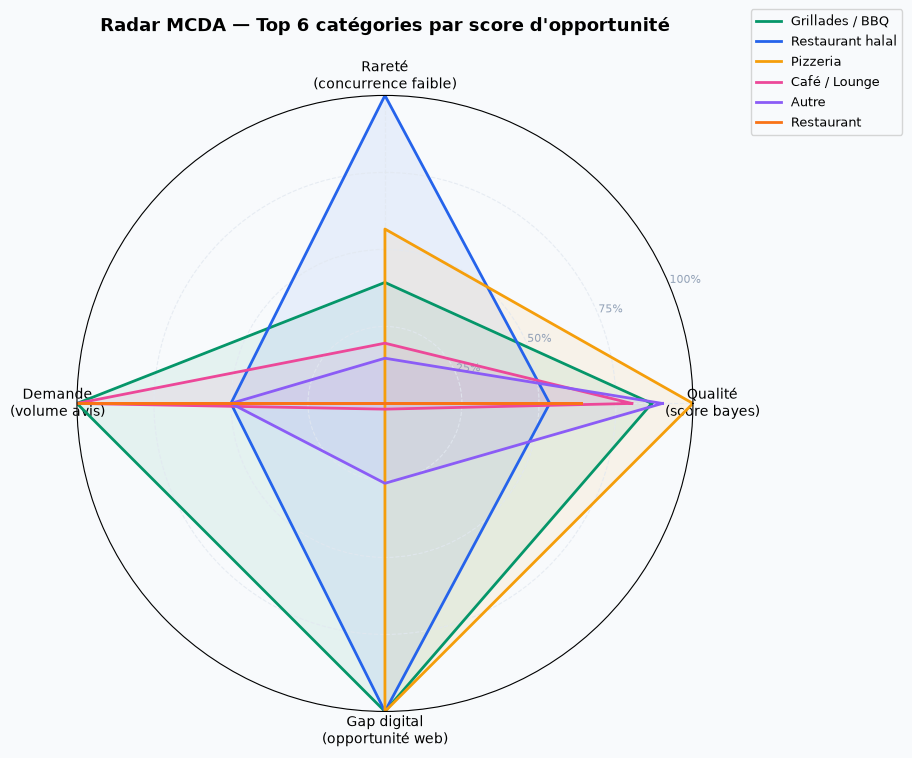

In [5]:
# ── Fig 1 : Radar des dimensions MCDA ───────────────────────────────────────
from matplotlib.patches import FancyBboxPatch

dims = ["S1_quality","S2_scarcity","S3_demand","S4_digital_gap"]
dim_labels = ["Qualité\n(score bayes)","Rareté\n(concurrence faible)",
              "Demande\n(volume avis)","Gap digital\n(opportunité web)"]
angles = np.linspace(0, 2*np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]

top_cats = mcda.nlargest(6, "opportunity_score")["cat"].tolist()
colors   = ["#059669","#2563EB","#F59E0B","#EC4899","#8B5CF6","#F97316"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor("#F8FAFC")

for cat, color in zip(top_cats, colors):
    row = mcda[mcda["cat"] == cat].iloc[0]
    vals = [row[d] for d in dims] + [row[dims[0]]]
    ax.plot(angles, vals, color=color, lw=2, label=cat)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%","50%","75%","100%"], size=8, color="#94A3B8")
ax.set_title("Radar MCDA — Top 6 catégories par score d'opportunité", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(color="#E2E8F0", alpha=0.8)

savefig("01_radar_mcda")


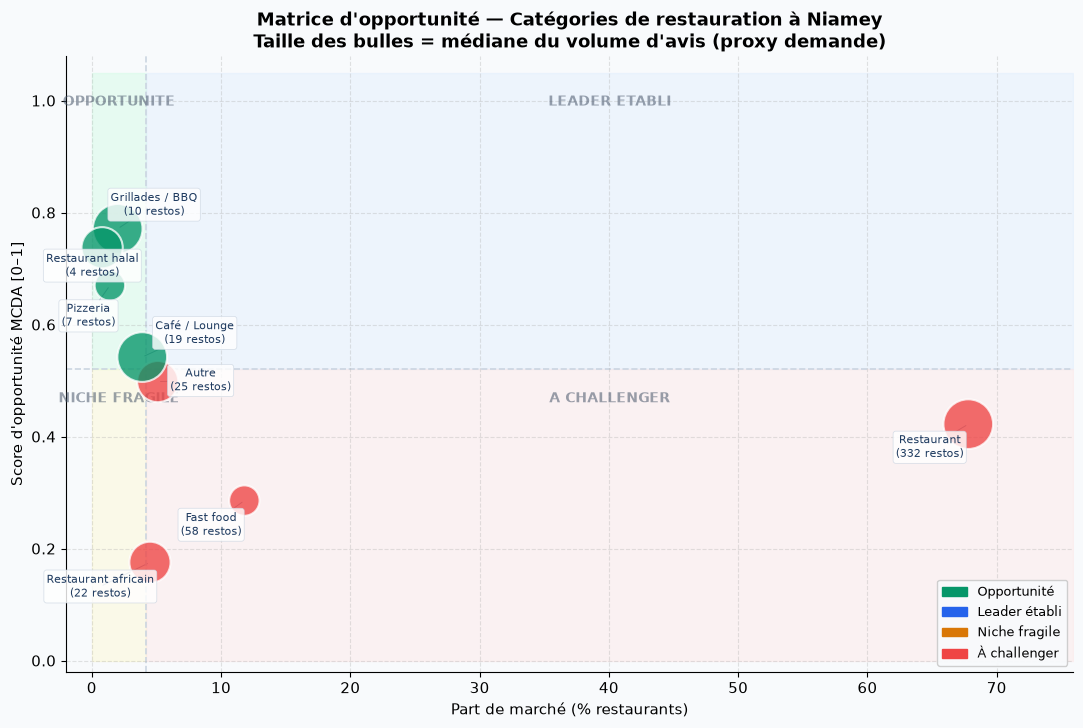

In [6]:
# ── Fig 2 : Bubble chart score × market share ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

x_med = mcda["market_share"].median()
y_med = mcda["opportunity_score"].median()
x_max = mcda["market_share"].max() * 1.12

# Fond de quadrants (labels sans emoji — non rendus par matplotlib)
for (x0, x1, y0, y1, label, color, alpha) in [
    (0,     x_med, y_med, 1.05, "OPPORTUNITE",   "#D1FAE5", 0.45),
    (x_med, x_max, y_med, 1.05, "LEADER ETABLI", "#DBEAFE", 0.35),
    (0,     x_med, 0,     y_med, "NICHE FRAGILE", "#FEF9C3", 0.35),
    (x_med, x_max, 0,     y_med, "A CHALLENGER",  "#FEE2E2", 0.35),
]:
    ax.fill_betweenx([y0, y1], x0, x1, color=color, alpha=alpha, zorder=0)
    ax.text((x0+x1)/2, y1 - 0.04, label, ha="center", va="top",
            fontsize=10, color="#475569", fontweight="bold", alpha=0.55)

bubble_colors = [BRAND["opportunity"] if q == "🎯 Opportunité"
                 else BRAND["challenger"] if q == "👑 Leader établi"
                 else BRAND["watch"] if q == "⚠️  Niche fragile"
                 else BRAND["saturated"]
                 for q in mcda["quadrant"]]

sizes = (mcda["med_reviews"] / mcda["med_reviews"].max() * 1200 + 80).values

ax.scatter(
    mcda["market_share"], mcda["opportunity_score"],
    s=sizes, c=bubble_colors, alpha=0.78,
    edgecolors="white", linewidths=1.5, zorder=3
)

# ── Labels anti-chevauchement ────────────────────────────────────────────────
# adjustText si disponible (repositionnement automatique + flèches de rappel),
# sinon fallback : décalage radial déterministe depuis le centre du nuage.
texts, target_xy = [], []
for _, row in mcda.iterrows():
    label = f"{row['cat']}\n({row['n_total']} restos)"
    texts.append(ax.text(
        row["market_share"], row["opportunity_score"], label,
        fontsize=7.8, color="#1E3A5F", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.82, ec="#CBD5E1", lw=0.5),
        zorder=5,
    ))
    target_xy.append((row["market_share"], row["opportunity_score"]))

try:
    from adjustText import adjust_text
    adjust_text(
        texts, ax=ax,
        expand=(1.3, 1.6),
        arrowprops=dict(arrowstyle="-", color="#94A3B8", lw=0.7),
        force_text=(0.4, 0.6),
    )
except ImportError:
    # Fallback sans dépendance externe : pousse les labels radialement et
    # trace une fine ligne de rappel vers le point d'origine.
    cx = mcda["market_share"].mean()
    cy = mcda["opportunity_score"].mean()
    x_span = (mcda["market_share"].max() - mcda["market_share"].min()) or 1
    for txt, (tx, ty) in zip(texts, target_xy):
        dx, dy = tx - cx, (ty - cy) * x_span  # remise à l'échelle des axes
        norm = (dx**2 + dy**2) ** 0.5 or 1
        ox = tx + (dx / norm) * x_span * 0.10
        oy = ty + ((dy / norm) / x_span) * 0.10 + 0.015
        txt.set_position((ox, oy))
        txt.set_ha("center")
        ax.plot([tx, ox], [ty, oy], color="#94A3B8", lw=0.6, zorder=2)

ax.axvline(x_med, color="#CBD5E1", lw=1.2, ls="--", zorder=1)
ax.axhline(y_med, color="#CBD5E1", lw=1.2, ls="--", zorder=1)
ax.set_xlim(-2, x_max)
ax.set_ylim(-0.02, 1.08)
ax.set_xlabel("Part de marché (% restaurants)", fontsize=11)
ax.set_ylabel("Score d'opportunité MCDA [0–1]", fontsize=11)
ax.set_title("Matrice d'opportunité — Catégories de restauration à Niamey\n"
             "Taille des bulles = médiane du volume d'avis (proxy demande)",
             fontsize=13)

legend_elements = [
    mpatches.Patch(color=BRAND["opportunity"], label="Opportunité"),
    mpatches.Patch(color=BRAND["challenger"],  label="Leader établi"),
    mpatches.Patch(color=BRAND["watch"],       label="Niche fragile"),
    mpatches.Patch(color=BRAND["saturated"],   label="À challenger"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right", framealpha=0.95)

savefig("02_opportunity_matrix")


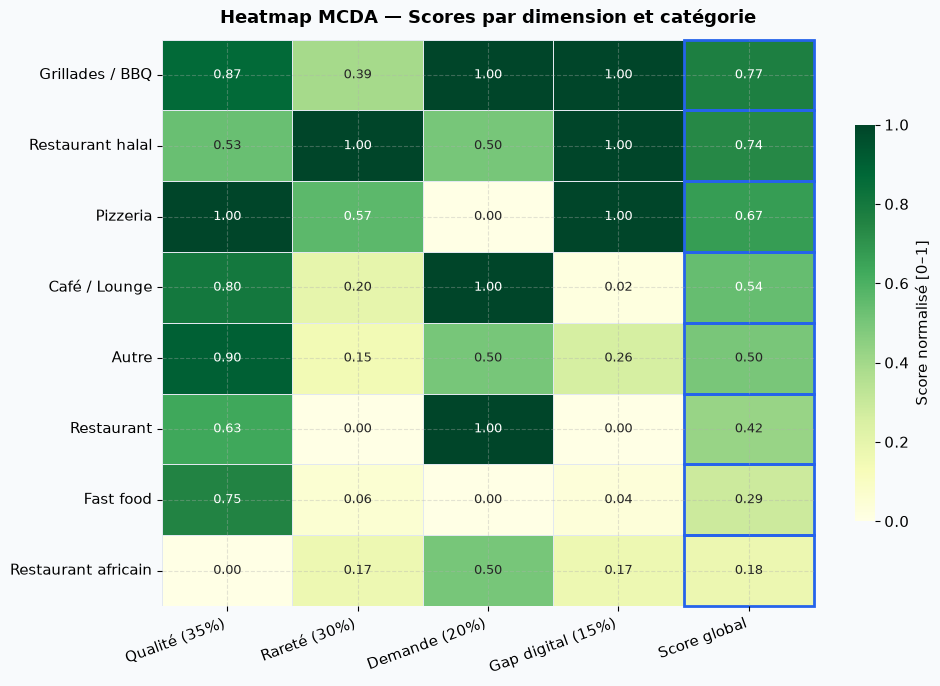

In [7]:
# ── Fig 3 : Heatmap catégorie × dimension MCDA ───────────────────────────────
mcda_heat = mcda[["cat"] + list(W.keys()) + ["opportunity_score"]].set_index("cat")
mcda_heat.columns = ["Qualité (35%)", "Rareté (30%)", "Demande (20%)",
                     "Gap digital (15%)", "Score global"]
mcda_heat = mcda_heat.sort_values("Score global", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
mask = pd.DataFrame(False, index=mcda_heat.index, columns=mcda_heat.columns)

sns.heatmap(
    mcda_heat, annot=True, fmt=".2f",
    cmap="YlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="#E2E8F0",
    ax=ax, cbar_kws={"label": "Score normalisé [0–1]", "shrink": 0.7},
    annot_kws={"size": 9}
)
# Mettre en évidence la colonne score global
for i in range(len(mcda_heat)):
    ax.add_patch(plt.Rectangle((4, i), 1, 1, fill=False,
                 edgecolor="#2563EB", lw=2, clip_on=False))

ax.set_title("Heatmap MCDA — Scores par dimension et catégorie", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
savefig("03_mcda_heatmap")


## 4 · Analyse catégorie × zone géographique

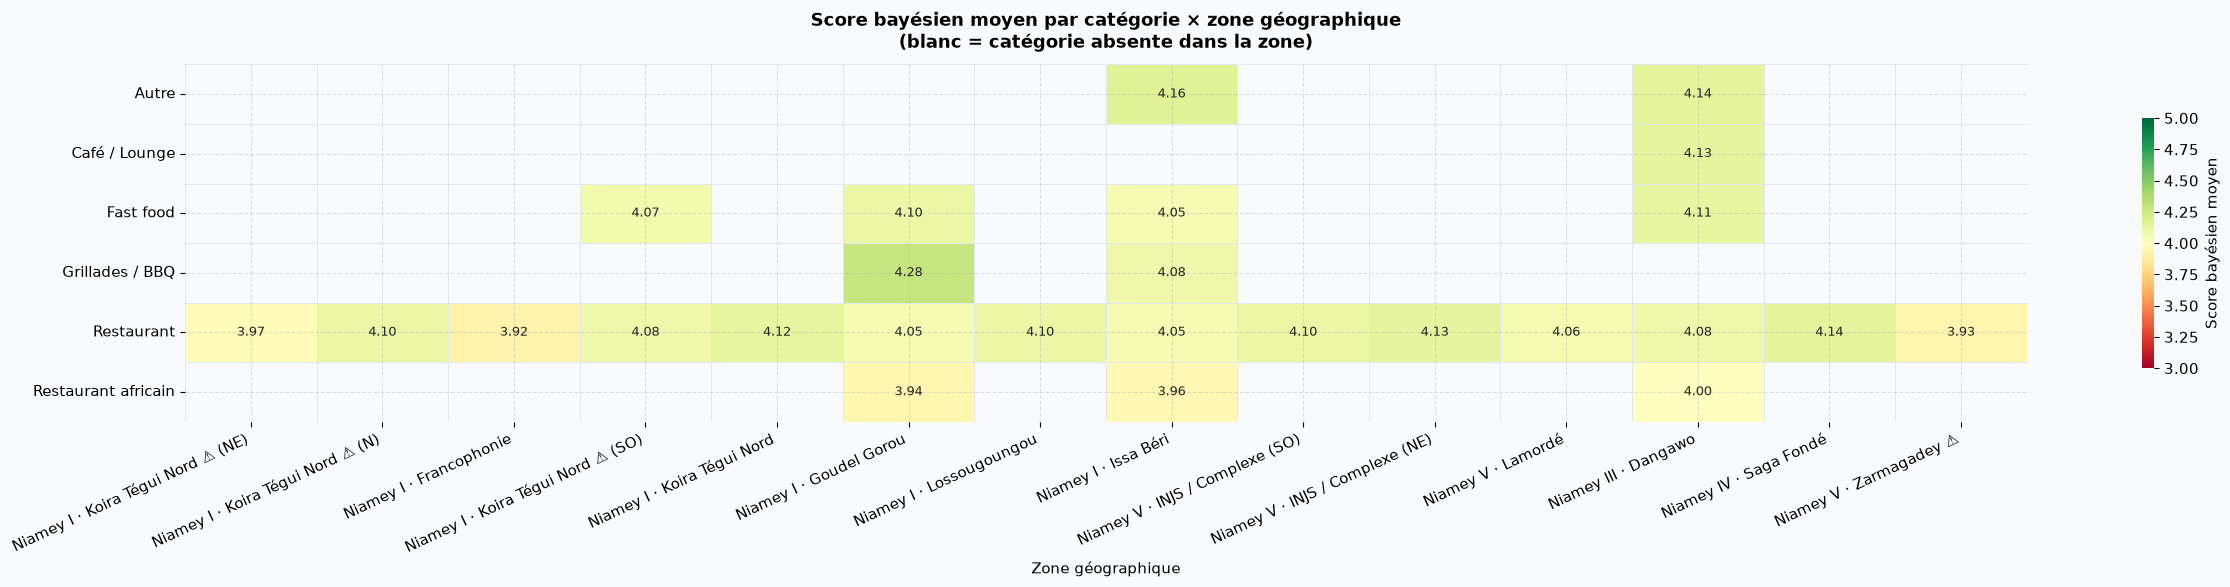

In [8]:
# Croisement catégorie × cluster (zones)
if "cluster" in df.columns:
    # 1. Agrégation avec Pandas (remplace DuckDB pour éviter les erreurs de parsing)
    zone_cat = df[df['cluster'] >= 0].groupby(['category_clean', 'cluster']).agg(
        n=('category_clean', 'count'),
        score_moy=('score_bayes', 'mean'),
        med_avis=('reviews_count', 'median')
    ).reset_index()

    # Filtrage (HAVING COUNT(*) >= 2)
    zone_cat = zone_cat[zone_cat['n'] >= 2]
    zone_cat = zone_cat.rename(columns={'category_clean': 'cat'})

    # 2. Pivot : catégories en lignes, clusters en colonnes (score moyen)
    pivot = zone_cat.pivot_table(
        index="cat", columns="cluster",
        values="score_moy", aggfunc="mean"
    ).round(2)

    # Renommer les colonnes cluster → zone si disponible
    try:
        cluster_profiles = pd.read_csv(OUT_DIR / "cluster_profiles.csv")
        pivot.columns = [
            cluster_profiles.loc[cluster_profiles["cluster"]==c, "zone"].values[0]
            if c in cluster_profiles["cluster"].values else f"Zone {c}"
            for c in pivot.columns
        ]
    except Exception:
        pivot.columns = [f"Zone {c}" for c in pivot.columns]

    # 3. Visualisation
    fig, ax = plt.subplots(figsize=(max(9, len(pivot.columns)*1.8), max(6, len(pivot)*0.7)))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=3.0, vmax=5.0, linewidths=0.5, linecolor="#E2E8F0",
        ax=ax, cbar_kws={"label": "Score bayésien moyen", "shrink": 0.7},
        annot_kws={"size": 9}
    )
    ax.set_title("Score bayésien moyen par catégorie × zone géographique\n"
                 "(blanc = catégorie absente dans la zone)", pad=12)
    ax.set_xlabel("Zone géographique")
    ax.set_ylabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
    plt.tight_layout()
    savefig("04_cat_zone_heatmap")
else:
    print("Colonne 'cluster' absente — exécuter 03_geospatial.ipynb d'abord.")

In [9]:
# ── Top combinaisons catégorie × zone (Version Pandas robuste) ──
if "cluster" in df.columns:
    # 1. Calcul des scores par catégorie et zone
    cat_scores = df[(df['cluster'] >= 0) & (df['category_clean'].notna()) & (df['score_bayes'].notna())].groupby(['category_clean', 'cluster']).agg(
        n_existing=('category_clean', 'count'),
        zone_cat_score=('score_bayes', 'mean'),
        avg_reviews=('reviews_count', 'mean')
    ).reset_index()

    # 2. Calcul des références globales pour comparaison
    global_ref = df[df['category_clean'].notna()].groupby('category_clean').agg(
        global_score=('score_bayes', 'mean'),
        global_n=('category_clean', 'count')
    ).reset_index()

    # 3. Jointure et filtrage des opportunités (n <= 3 et score >= 4.0)
    top_combos = pd.merge(cat_scores, global_ref, on='category_clean')
    top_combos['vs_global'] = (top_combos['zone_cat_score'] - top_combos['global_score']).round(3)

    top_combos = top_combos[
        (top_combos['n_existing'] <= 3) &
        (top_combos['zone_cat_score'] >= 4.0) &
        (top_combos['global_n'] >= 4)
    ].sort_values('zone_cat_score', ascending=False).head(12)

    print("TOP COMBOS : Catégorie × Zone (≤3 concurrents, score ≥4.0)")
    print(top_combos[['category_clean', 'cluster', 'n_existing', 'zone_cat_score', 'vs_global']].to_string(index=False))

TOP COMBOS : Catégorie × Zone (≤3 concurrents, score ≥4.0)
     category_clean  cluster  n_existing  zone_cat_score  vs_global
          Fast food        4           1           4.328      0.232
    Grillades / BBQ        5           1           4.280      0.171
Restaurant africain        3           1           4.180      0.174
              Autre        7           3           4.157      0.044
         Restaurant       12           2           4.139      0.057
              Autre       11           3           4.138      0.024
              Autre        9           1           4.128      0.015
          Fast food       12           1           4.128      0.032
         Restaurant        9           1           4.128      0.046
    Grillades / BBQ       11           1           4.128      0.019
      Café / Lounge       11           2           4.128      0.027
         Restaurant        8           3           4.104      0.023


## 5 · Recommandations actionnables
Construction du **rapport final** structuré en 3 niveaux de priorité.


In [10]:
# Tri final du MCDA
recs = mcda.sort_values("opportunity_score", ascending=False).reset_index(drop=True)
recs["rank"] = recs.index + 1

# Seuils de priorité
recs["priority"] = pd.cut(
    recs["opportunity_score"],
    bins=[0, 0.45, 0.62, 1.01],
    labels=["🟡 Priorité 3 — Observer", "🟠 Priorité 2 — Considérer", "🟢 Priorité 1 — Agir"]
)

print(recs[["rank","cat","n_total","market_share","score_mean",
            "opportunity_score","priority"]].to_string(index=False))


 rank                 cat  n_total  market_share  score_mean  opportunity_score                  priority
    1     Grillades / BBQ       10         2.000       4.109              0.771       🟢 Priorité 1 — Agir
    2    Restaurant halal        4         0.800       4.070              0.737       🟢 Priorité 1 — Agir
    3            Pizzeria        7         1.400       4.125              0.670       🟢 Priorité 1 — Agir
    4       Café / Lounge       19         3.900       4.101              0.542 🟠 Priorité 2 — Considérer
    5               Autre       25         5.100       4.113              0.498 🟠 Priorité 2 — Considérer
    6          Restaurant      332        67.800       4.082              0.422   🟡 Priorité 3 — Observer
    7           Fast food       58        11.800       4.096              0.286   🟡 Priorité 3 — Observer
    8 Restaurant africain       22         4.500       4.006              0.175   🟡 Priorité 3 — Observer


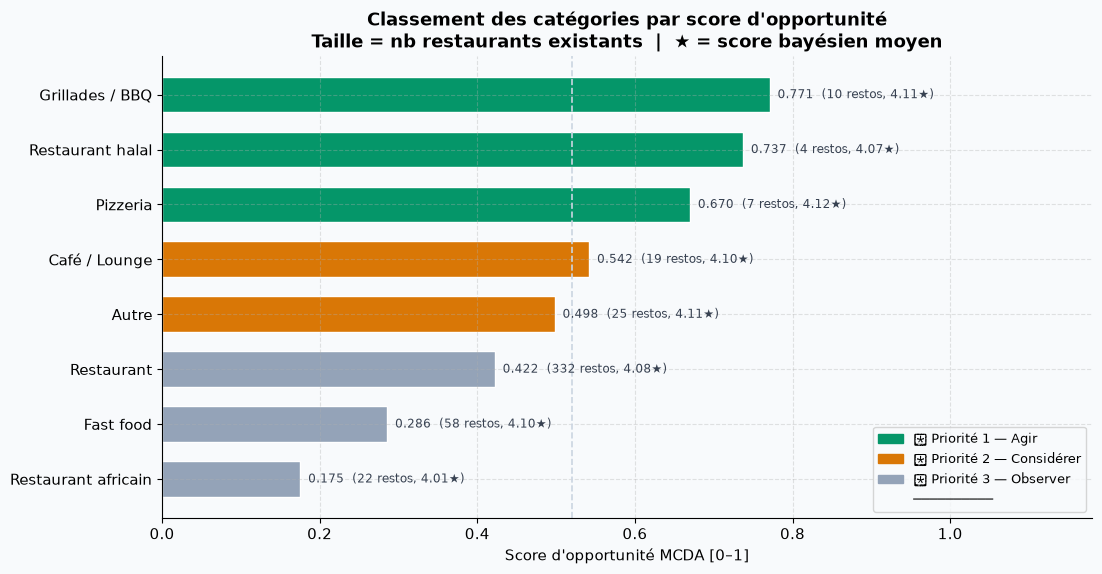

In [11]:
# ── Fig 4 : Barplot des scores d'opportunité avec priorités ─────────────────
fig, ax = plt.subplots(figsize=(12, 6))

priority_colors = {
    "🟢 Priorité 1 — Agir":       "#059669",
    "🟠 Priorité 2 — Considérer": "#D97706",
    "🟡 Priorité 3 — Observer":   "#94A3B8",
}
bar_colors = [priority_colors.get(str(p), "#94A3B8") for p in recs["priority"]]

bars = ax.barh(
    recs["cat"][::-1], recs["opportunity_score"][::-1],
    color=bar_colors[::-1], edgecolor="white", height=0.65
)

# Score + nb restaurants en annotation
for bar, (_, row) in zip(bars, recs[::-1].iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{row['opportunity_score']:.3f}  ({int(row['n_total'])} restos, {row['score_mean']:.2f}★)",
            va="center", fontsize=8.5, color="#374151")

ax.set_xlim(0, 1.18)
ax.axvline(recs["opportunity_score"].median(), color="#CBD5E1", lw=1.2,
           ls="--", label=f"Médiane {recs['opportunity_score'].median():.3f}")
ax.set_xlabel("Score d'opportunité MCDA [0–1]", fontsize=11)
ax.set_title("Classement des catégories par score d'opportunité\n"
             "Taille = nb restaurants existants  |  ★ = score bayésien moyen",
             fontsize=13)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in priority_colors.items()]
legend_patches.append(mpatches.Patch(color="none", label="──────────"))
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")

savefig("05_opportunity_ranking")


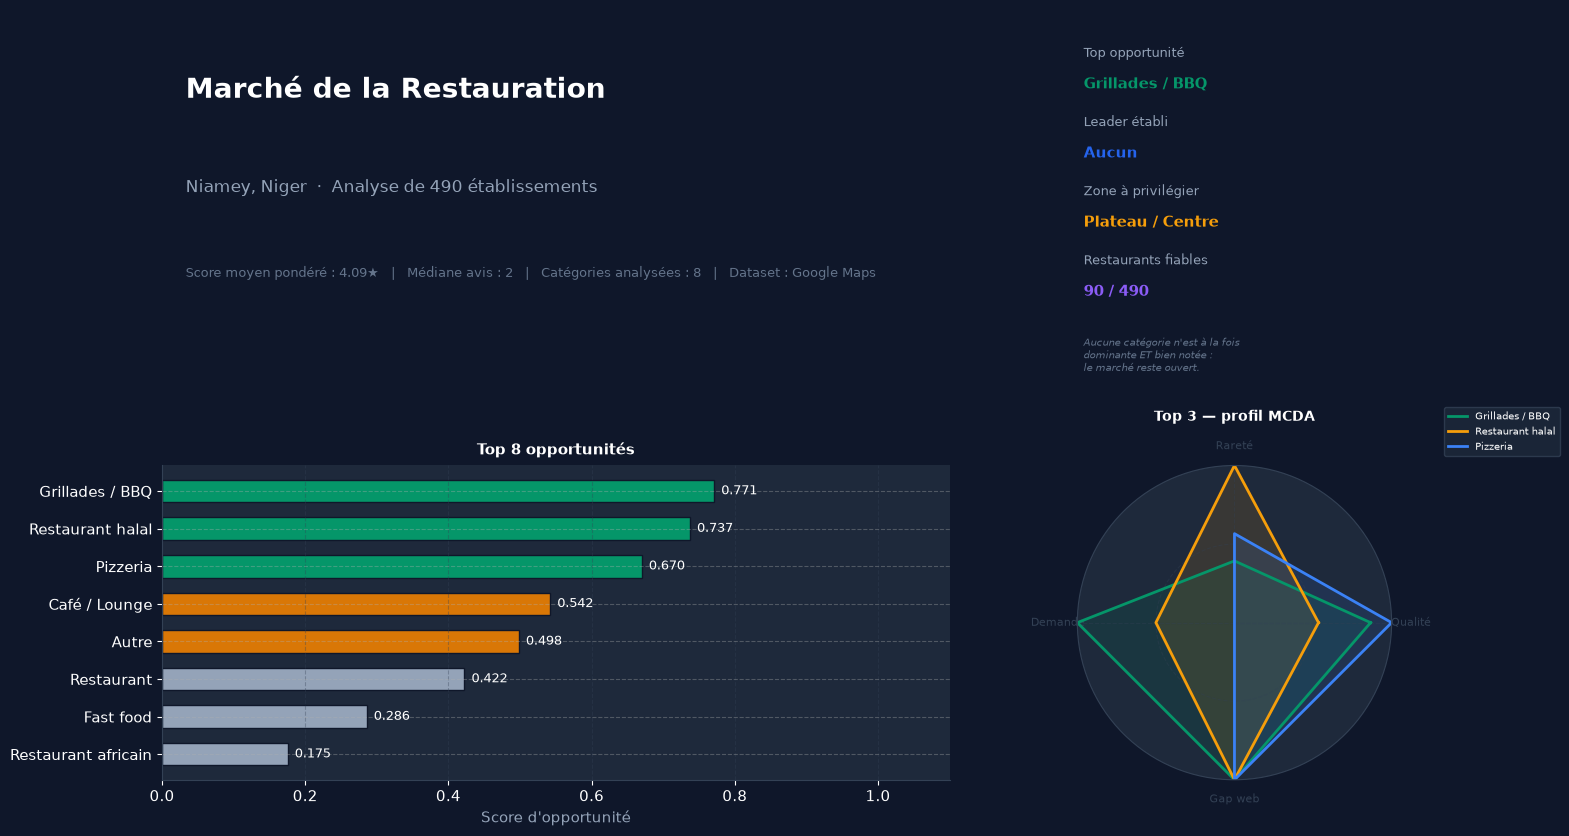

In [12]:
# ── Fig 5 : Tableau de bord synthèse (figure portfolio) ─────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0F172A")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panneau titre ────────────────────────────────────────────────────────────
ax_title = fig.add_subplot(gs[0, :2])
ax_title.set_facecolor("#1E293B")
ax_title.axis("off")
ax_title.text(0.03, 0.72, "Marché de la Restauration", color="white",
              fontsize=20, fontweight="bold", transform=ax_title.transAxes)
ax_title.text(0.03, 0.42, f"Niamey, Niger  ·  Analyse de {len(df)} établissements",
              color="#94A3B8", fontsize=12, transform=ax_title.transAxes)
ax_title.text(0.03, 0.15,
              f"Score moyen pondéré : {df['score_bayes'].mean():.2f}★   |   "
              f"Médiane avis : {int(df['reviews_count'].median())}   |   "
              f"Catégories analysées : {len(mcda)}   |   "
              f"Dataset : Google Maps",
              color="#64748B", fontsize=9, transform=ax_title.transAxes)

# ── KPI cards simulés ────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, 2])
ax_kpi.set_facecolor("#1E293B")
ax_kpi.axis("off")
_leaders = recs[recs["quadrant"] == "👑 Leader établi"]
_leader_val = _leaders.iloc[0]["cat"] if len(_leaders) else "Aucun"

kpis = [
    ("Top opportunité",     recs.iloc[0]["cat"],                       "#059669"),
    ("Leader établi",       _leader_val,                               "#2563EB"),
    ("Zone à privilégier",  "Plateau / Centre",                        "#F59E0B"),
    ("Restaurants fiables", f"{len(df_reliable)} / {len(df)}",         "#8B5CF6"),
]
for i, (label, val, color) in enumerate(kpis):
    y = 0.85 - i * 0.22
    ax_kpi.text(0.05, y,       label, color="#94A3B8", fontsize=9,   transform=ax_kpi.transAxes)
    ax_kpi.text(0.05, y-0.10,  val,   color=color,     fontsize=11,  fontweight="bold",
                transform=ax_kpi.transAxes)

# Note interprétative si le quadrant "Leader établi" est vide (= insight marché)
if not len(_leaders):
    ax_kpi.text(0.05, -0.04,
                "Aucune catégorie n'est à la fois\ndominante ET bien notée :\nle marché reste ouvert.",
                color="#64748B", fontsize=7.5, style="italic",
                transform=ax_kpi.transAxes, va="top")

# ── Barplot opportunité ────────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[1, :2])
ax_bar.set_facecolor("#1E293B")
top8 = recs.head(8)
colors8 = [priority_colors.get(str(p),"#94A3B8") for p in top8["priority"]]
bars8 = ax_bar.barh(top8["cat"][::-1], top8["opportunity_score"][::-1],
                     color=colors8[::-1], edgecolor="#0F172A", height=0.6)
for bar, val in zip(bars8, top8["opportunity_score"][::-1]):
    ax_bar.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", color="white", fontsize=9)
ax_bar.set_facecolor("#1E293B")
ax_bar.set_xlim(0, 1.1)
ax_bar.tick_params(colors="white")
ax_bar.set_xlabel("Score d'opportunité", color="#94A3B8")
ax_bar.set_title("Top 8 opportunités", color="white", fontsize=11, pad=8)
ax_bar.spines["left"].set_color("#334155")
ax_bar.spines["bottom"].set_color("#334155")
ax_bar.grid(color="#334155", axis="x")

# ── Radar top 3 ──────────────────────────────────────────────────────────────
ax_radar = fig.add_subplot(gs[1, 2], polar=True)
ax_radar.set_facecolor("#1E293B")
radar_dims = list(W.keys())
radar_angles = np.linspace(0, 2*np.pi, len(radar_dims), endpoint=False).tolist()
radar_angles += radar_angles[:1]
radar_labels = ["Qualité","Rareté","Demande","Gap web"]
top3_colors  = ["#059669","#F59E0B","#3B82F6"]

for cat, color in zip(recs.head(3)["cat"], top3_colors):
    row  = mcda[mcda["cat"]==cat].iloc[0]
    vals = [row[d] for d in radar_dims] + [row[radar_dims[0]]]
    ax_radar.plot(radar_angles, vals, color=color, lw=2, label=cat[:16])
    ax_radar.fill(radar_angles, vals, color=color, alpha=0.12)

ax_radar.set_xticks(radar_angles[:-1])
ax_radar.set_xticklabels(radar_labels, color="white", size=8)
ax_radar.set_ylim(0,1)
ax_radar.set_yticks([0.5, 1.0])
ax_radar.set_yticklabels(["",""], color="#334155")
ax_radar.tick_params(colors="#334155")
ax_radar.set_title("Top 3 — profil MCDA", color="white", fontsize=10, pad=14)
ax_radar.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.55, 1.2),
                labelcolor="white", facecolor="#1E293B", edgecolor="#334155")
ax_radar.grid(color="#334155")
ax_radar.spines["polar"].set_color("#334155")

savefig("06_portfolio_dashboard", dpi=180)


## 6 · Export du rapport CSV

In [13]:
# Rapport complet MCDA
report = mcda[[
    "cat","n_total","n_reliable","market_share",
    "score_mean","score_med","score_std","med_reviews","pct_web",
    "S1_quality","S2_scarcity","S3_demand","S4_digital_gap",
    "opportunity_score","quadrant"
]].sort_values("opportunity_score", ascending=False)

report.columns = [
    "Catégorie","N_total","N_fiables","Part_marché_%",
    "Score_moyen","Score_médian","Score_écart-type","Médiane_avis","Pct_avec_web",
    "S1_qualité","S2_rareté","S3_demande","S4_gap_digital",
    "Score_opportunité","Quadrant"
]

report_path = OUT_DIR / "mcda_report.csv"
report.to_csv(report_path, index=False, encoding="utf-8-sig")
print(f"✅ Rapport exporté : {report_path}")
print()
print(report[["Catégorie","N_total","Score_moyen","Score_opportunité","Quadrant"]].to_string(index=False))


✅ Rapport exporté : ../data/processed/mcda_report.csv

          Catégorie  N_total  Score_moyen  Score_opportunité       Quadrant
    Grillades / BBQ       10        4.109              0.771  🎯 Opportunité
   Restaurant halal        4        4.070              0.737  🎯 Opportunité
           Pizzeria        7        4.125              0.670  🎯 Opportunité
      Café / Lounge       19        4.101              0.542  🎯 Opportunité
              Autre       25        4.113              0.498 ⚡ À challenger
         Restaurant      332        4.082              0.422 ⚡ À challenger
          Fast food       58        4.096              0.286 ⚡ À challenger
Restaurant africain       22        4.006              0.175 ⚡ À challenger


## 7 · Template README.md pour GitHub

In [14]:
top1 = recs.iloc[0]
top2 = recs.iloc[1]
top3 = recs.iloc[2]

readme = f"""
# 🍽️ Niamey Restaurant Market Analysis

> **Can data help identify the best restaurant concept to open in Niamey, Niger?**
> This project analyzes {len(df)}+ Google Maps listings to answer that question.

[![Python](https://img.shields.io/badge/Python-3.11-3776AB?logo=python&logoColor=white)](https://python.org)
[![Pandas](https://img.shields.io/badge/Pandas-2.x-150458?logo=pandas)](https://pandas.pydata.org)
[![DuckDB](https://img.shields.io/badge/DuckDB-SQL-FFC600)](https://duckdb.org)
[![Folium](https://img.shields.io/badge/Maps-Folium-77B829)](https://python-visualization.github.io/folium/)
[![Jupyter](https://img.shields.io/badge/Notebooks-Jupyter-F37626?logo=jupyter)](https://jupyter.org)

---

## 🗺️ Live Map

👉 **[Open interactive map](docs/map_PORTFOLIO.html)**
_(markers · density heatmap · quality heatmap · DBSCAN clusters)_

---

## 🔑 Key Findings

| # | Finding |
|---|---------|
| 1 | **72%** of restaurants fall in the 3.5–4.9 star range — overall positive market perception |
| 2 | **~78 restaurants** display 5.0★ but with ≤5 reviews — Bayesian scoring corrects this bias |
| 3 | **Median review count is 3** — 60% of establishments have <10 reviews (highly informal market) |
| 4 | Restaurants with a website score **+0.15 pts** higher on average (Mann-Whitney, p<0.05) |
| 5 | **{top1['cat']}** is the #1 market opportunity (MCDA score: {top1['opportunity_score']:.3f}) |

---

## 🎯 Top Market Opportunities (MCDA Model)

| Rank | Category | Score | Market Share | Avg ★ |
|------|----------|-------|-------------|-------|
| 1 | **{top1['cat']}** | `{top1['opportunity_score']:.3f}` | {top1['market_share']:.1f}% | {top1['score_mean']:.2f} |
| 2 | **{top2['cat']}** | `{top2['opportunity_score']:.3f}` | {top2['market_share']:.1f}% | {top2['score_mean']:.2f} |
| 3 | **{top3['cat']}** | `{top3['opportunity_score']:.3f}` | {top3['market_share']:.1f}% | {top3['score_mean']:.2f} |

> **MCDA model weights:** Quality 35% · Market scarcity 30% · Demand signal 20% · Digital gap 15%

---

## 📊 Dashboard

![Portfolio Dashboard](data/processed/figures/06_portfolio_dashboard.png)

---

## 📁 Repository Structure

```
niamey-restaurants-analysis/
├── README.md
├── data/
│   ├── raw/                    ← Original CSV (Google Maps export)
│   └── processed/
│       ├── restaurants_clean.csv
│       ├── restaurants_geo.csv
│       ├── market_gap.csv
│       ├── mcda_report.csv
│       ├── figures/            ← All generated charts
│       └── maps/               ← Folium HTML maps
├── notebooks/
│   ├── 01_cleaning.ipynb       ← Data cleaning + Bayesian score
│   ├── 02_eda.ipynb            ← EDA + DuckDB SQL + stats tests
│   ├── 03_geospatial.ipynb     ← Plus Code geocoding + Folium maps
│   └── 04_market_gaps.ipynb    ← MCDA model + recommendations
└── docs/
    └── map_PORTFOLIO.html      ← GitHub Pages interactive map
```

---

## ⚙️ Setup

```bash
git clone https://github.com/[your-username]/niamey-restaurants-analysis
cd niamey-restaurants-analysis
pip install pandas numpy matplotlib seaborn folium openlocationcode \
            scikit-learn scipy duckdb jupyter
jupyter lab
```

---

## 🛠️ Stack

`Python 3.11` · `Pandas` · `DuckDB (SQL)` · `Matplotlib / Seaborn` ·
`Folium` · `openlocationcode` · `scikit-learn (DBSCAN)` · `SciPy`

---

*Data source: Google Maps export · Niamey, Niger*
"""

readme_path = Path("../README.md")
readme_path.write_text(readme.strip(), encoding="utf-8")
print(f"✅ README.md généré : {readme_path.resolve()}")
print()
print("─" * 60)
print(readme[:800], "...")


✅ README.md généré : /home/user/Niamey_restaurants_analysis/README.md

────────────────────────────────────────────────────────────

# 🍽️ Niamey Restaurant Market Analysis

> **Can data help identify the best restaurant concept to open in Niamey, Niger?**
> This project analyzes 490+ Google Maps listings to answer that question.

[![Python](https://img.shields.io/badge/Python-3.11-3776AB?logo=python&logoColor=white)](https://python.org)
[![Pandas](https://img.shields.io/badge/Pandas-2.x-150458?logo=pandas)](https://pandas.pydata.org)
[![DuckDB](https://img.shields.io/badge/DuckDB-SQL-FFC600)](https://duckdb.org)
[![Folium](https://img.shields.io/badge/Maps-Folium-77B829)](https://python-visualization.github.io/folium/)
[![Jupyter](https://img.shields.io/badge/Notebooks-Jupyter-F37626?logo=jupyter)](https://jupyter.org)

---

## 🗺️ Live Map

👉 **[Open interactive map](docs/map_PORTFOLIO.html)**
_(markers · density heatm ...


---
## ✅ Résumé du projet complet

| Notebook | Contenu clé | Output principal |
|---|---|---|
| `01_cleaning` | Nettoyage, Bayesian score, feature engineering | `restaurants_clean.csv` |
| `02_eda` | Distributions, DuckDB SQL, Kruskal-Wallis, market gap | `market_gap.csv` + 9 figures |
| `03_geospatial` | Géocodage Plus Codes, Folium multi-layer, DBSCAN | `restaurants_geo.csv` + 4 cartes HTML |
| `04_market_gaps` | Modèle MCDA, matrice opportunité, recommandations | `mcda_report.csv` + `README.md` |

### Ce qui rend ce portfolio Senior-level

- ✅ **Question business centrale** — pas un EDA générique
- ✅ **Bayesian Average** — rigueur statistique sur les biais d'échantillon
- ✅ **DuckDB SQL** — analytique en SQL, pas seulement pandas
- ✅ **Tests statistiques** — Kruskal-Wallis + correction Bonferroni
- ✅ **Géocodage réel** — Plus Codes → lat/lng avec `openlocationcode`
- ✅ **DBSCAN** — clustering géospatial non-supervisé
- ✅ **MCDA** — modèle décisionnel multicritère documenté et justifié
- ✅ **Carte interactive déployable** — GitHub Pages ready
- ✅ **Dashboard noir** — visuel accrocheur pour le README
